# LiDAR Power Line Analysis

In this notebook we analyze a LiDAR point cloud of power transmission lines.

The objectives are:
- detect the number of cables
- separate the points belonging to each wire
- estimate the plane containing each cable
- fit a catenary curve to model the shape of the wires

In [15]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lidar_catenary.io import load_point_cloud

from lidar_catenary.preprocessing import (
    estimate_wire_directions,
    project_perpendicular
)

from lidar_catenary.clustering import (
    estimate_number_of_wires,
    cluster_wires
)

from lidar_catenary.modeling import fit_wire_catenary

from lidar_catenary.catenary import catenary

from lidar_catenary.visualization import (
    plot_point_cloud_3d,
    plot_projections,
    plot_height_distribution,
    plot_clusters_2d,
    plot_clusters_3d,
    plot_wire_fit,
    plot_catenary_fit_planes,
    plot_all_catenaries
)

## Load the dataset

The LiDAR data is stored in a `.parquet` file.  
Each row represents a point detected by the sensor with coordinates (x, y, z).

We first load the dataset and inspect its structure.

In [16]:
df = load_point_cloud("..\data\lidar_cable_points_extrahard.parquet")

df.head()

,x,y,z
2211,6.037626,-13.231044,10.527397
2905,-10.721094,17.124476,10.943132
1411,2.893274,-3.527691,10.035204
251,5.870610,-10.909318,10.419144
794,-7.155748,12.846815,10.556583


In [17]:
points = df[["x","y","z"]].values

print(points.shape)

(1201, 3)


## 3D visualization

We start by visualizing the LiDAR point cloud in 3D.

This helps understand:
- the orientation of the wires
- the presence of multiple cables
- the characteristic sag of power lines.

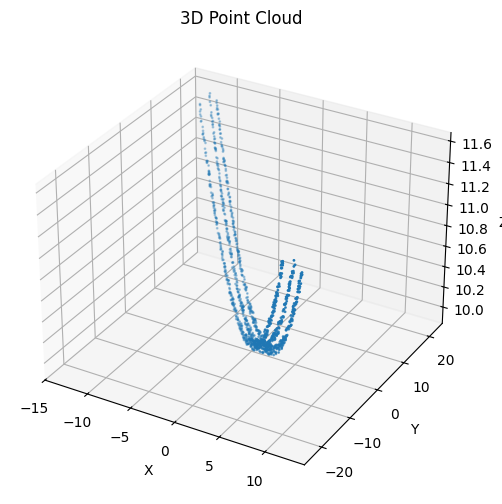

In [18]:
plot_point_cloud_3d(points)

## 2D projections

To better understand the structure of the data we visualize projections of the point cloud onto different planes.

The XY projection shows that the cables are roughly parallel, which will help us separate them later.

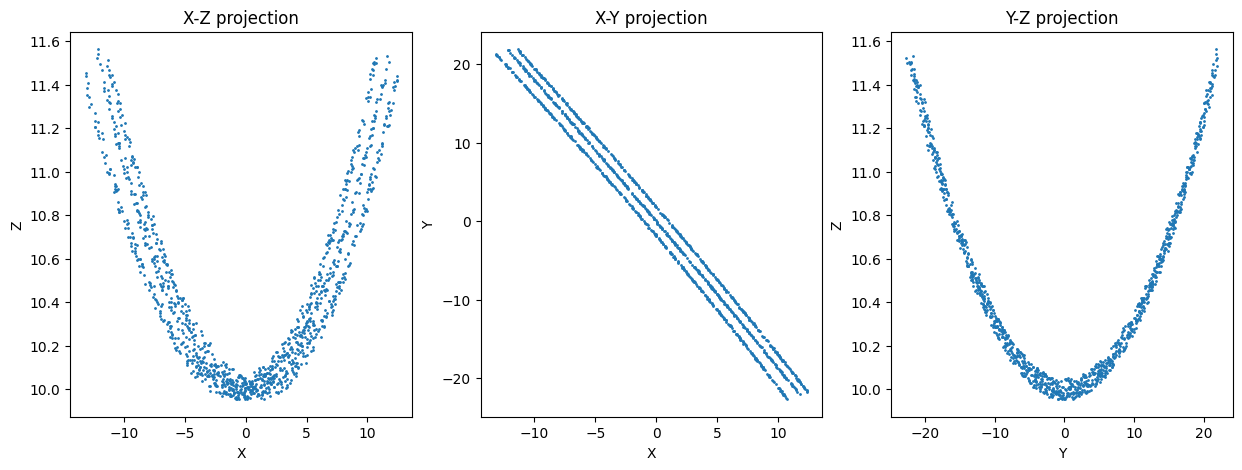

In [19]:
plot_projections(points)

## Height distribution

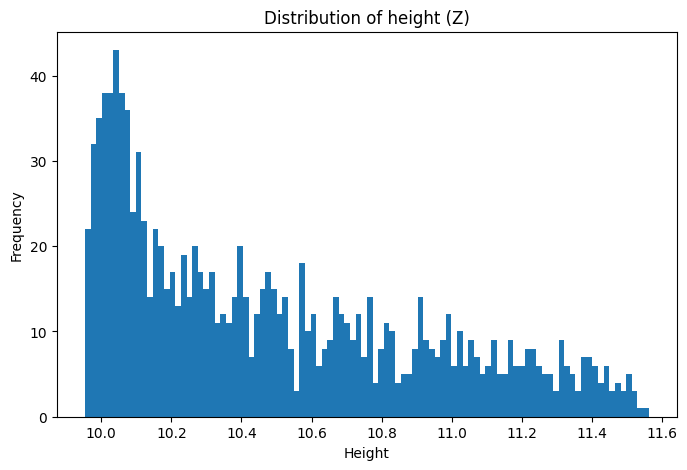

In [20]:
plot_height_distribution(points)

## Estimating the wire direction

We use Principal Component Analysis (PCA) on the horizontal coordinates to estimate the main direction of the cables.

The first component corresponds to the direction along the wires, while the second component separates the cables.

In [21]:
direction, perp_direction = estimate_wire_directions(points)

print("Wire direction:", direction)
print("Perpendicular direction:", perp_direction)

Wire direction: [-0.47925363  0.87767645]
Perpendicular direction: [0.87767645 0.47925363]


## Projection

To separate the wires, we project the points onto the direction perpendicular to the cables.

In this one-dimensional representation, each wire forms a distinct group of points.

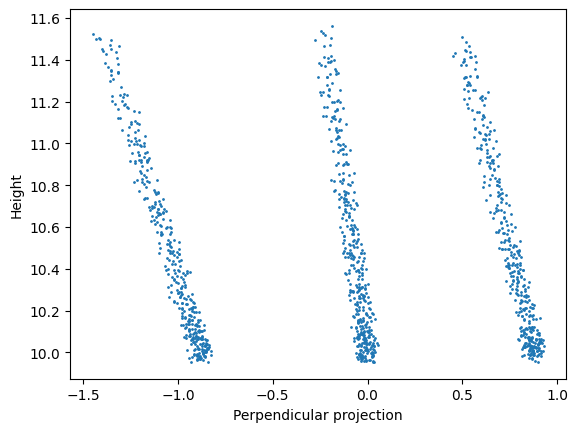

In [22]:
projection = project_perpendicular(points, perp_direction)

plt.figure()

plt.scatter(
    projection,
    points[:,2],
    s=1
)

plt.xlabel("Perpendicular projection")
plt.ylabel("Height")

plt.show()

## Find number of wires

In [23]:
k = estimate_number_of_wires(projection)

print("Estimated number of wires:", k)

Estimated number of wires: 3


## Clustering the wires

We apply a clustering algorithm to the projected points in order to identify individual cables.

Each cluster corresponds to a different wire.

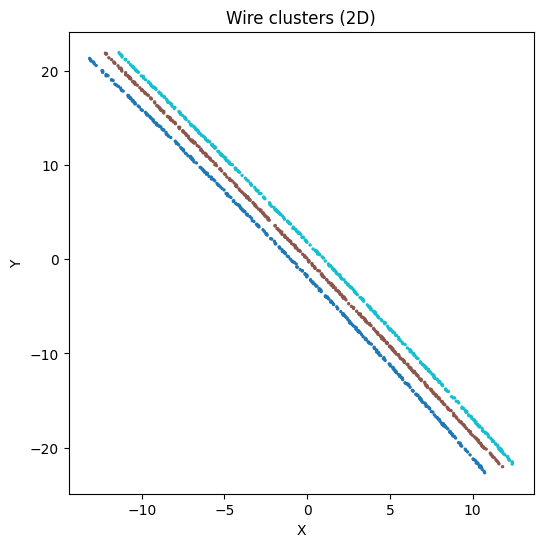

In [24]:
labels = cluster_wires(projection, k)

plot_clusters_2d(points, labels)

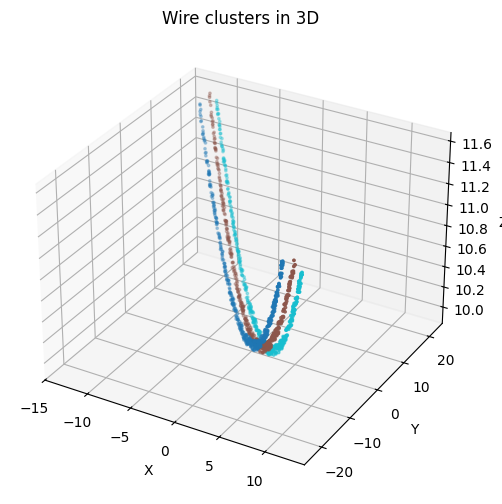

In [25]:
plot_clusters_3d(points, labels)

## Catenary fitting

Power transmission cables follow a catenary shape due to gravity.

For each cluster, we project the points along the cable direction and fit a catenary model relating the horizontal distance s and the height z.

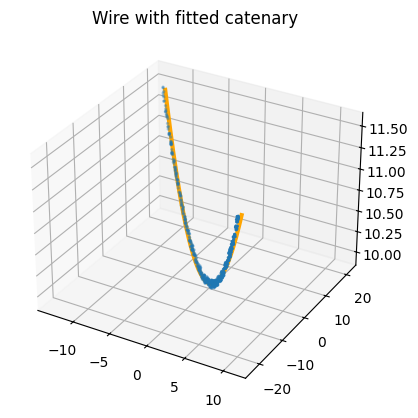

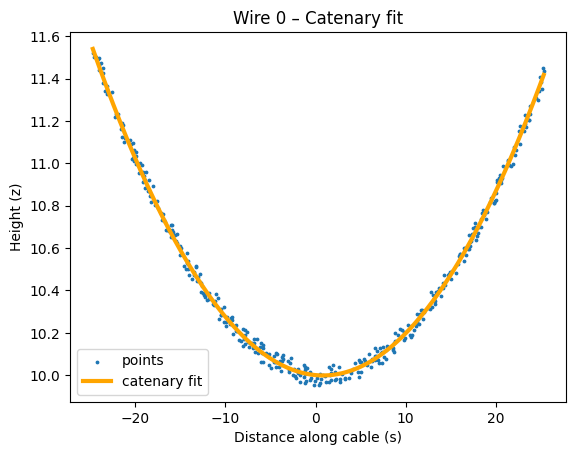

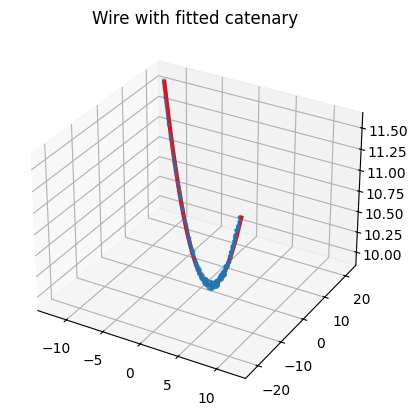

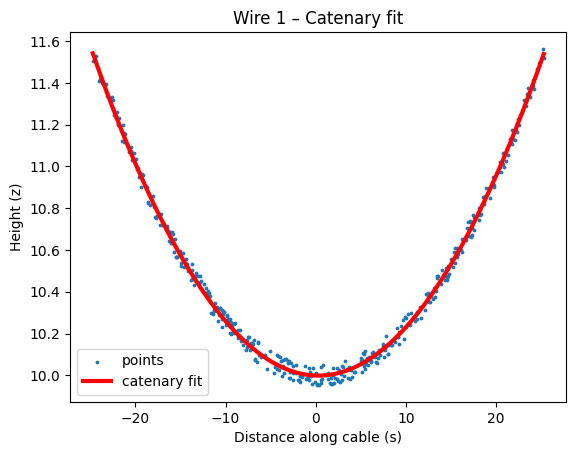

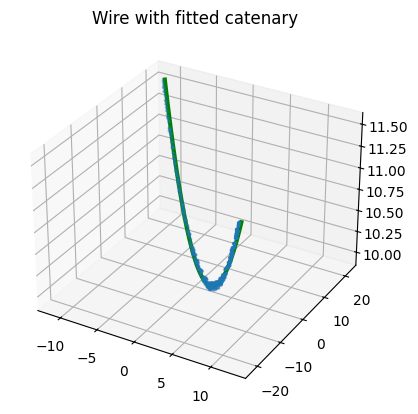

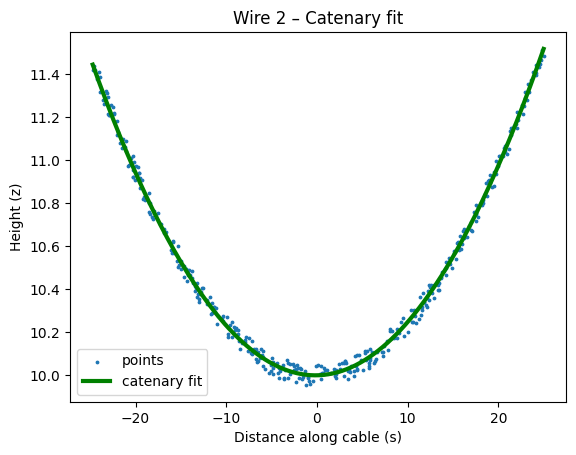

In [26]:
import matplotlib.pyplot as plt

wire_models = []
list_p0 = []
list_s = []

unique_labels = np.unique(labels)

colors = ["orange", "red", "green","pink","purple","yellow","cyan"]

for i, label in enumerate(unique_labels):

    wire_points = points[labels == label]

    params, p0, s_vals = fit_wire_catenary(
        wire_points,
        direction
    )

    wire_models.append(params)
    list_p0.append(p0)
    list_s.append(s_vals)

    s_plot = np.linspace(min(s_vals), max(s_vals), 200)

    z_plot = catenary(s_plot, *params)

    color = colors[i]

    # 3D plot
    plot_wire_fit(
        wire_points,
        s_plot,
        z_plot,
        direction,
        p0,
        color=color
    )

    # 2D plot (important pour vérifier la qualité du fit)
    plt.figure()

    plt.scatter(
        s_vals,
        wire_points[:,2],
        s=3,
        label="points"
    )

    plt.plot(
        s_plot,
        z_plot,
        color=color,
        linewidth=3,
        label="catenary fit"
    )

    plt.xlabel("Distance along cable (s)")
    plt.ylabel("Height (z)")
    plt.title(f"Wire {i} – Catenary fit")

    plt.legend()

    plt.show()

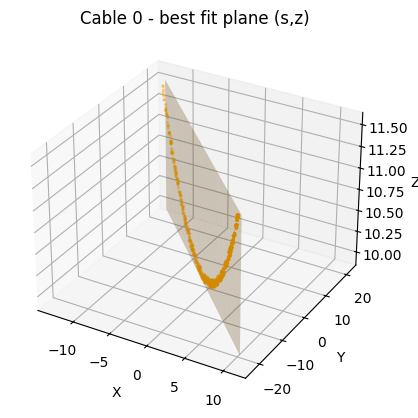

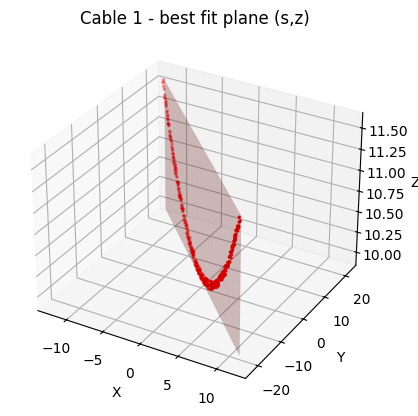

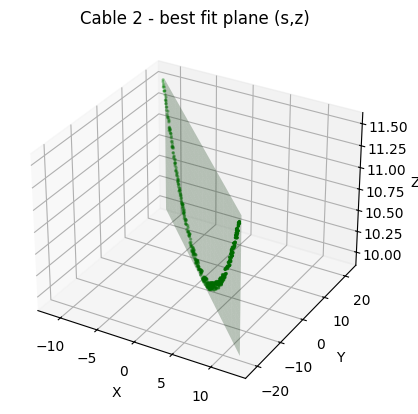

In [27]:
plot_catenary_fit_planes(
    points,
    labels,
    wire_models,
    list_p0,
    list_s,
    direction,
    colors
)

## Final 3D reconstruction

Using the fitted parameters, we reconstruct the cables in 3D space and visualize them together with the original LiDAR point cloud.

Each cable is displayed with a different color.

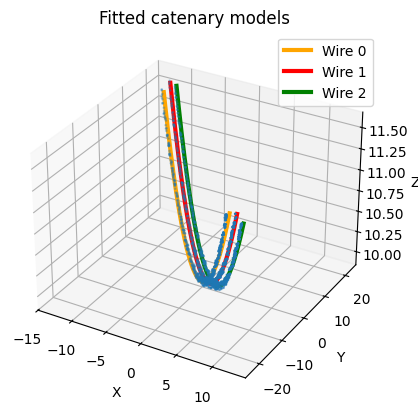

In [28]:
plot_all_catenaries(
    points,
    wire_models,
    list_p0,
    list_s,
    direction,
    colors
)